In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

print("GPU Available:")
print(tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz

--2026-09-25 17:07:56--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2026-09-25 17:07:58--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [application/octet-stream]
Saving to: ‘images.tar.gz’

images.tar.gz       100%[===================>] 755.23M  21.0MB/s    in 36s     

2026-09-25 17:08:35 (20.8 MB/s) - ‘images.tar.gz’ saved [791918971/791918971]

--2026-09-25 17:08:36--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
Resolving www.r

In [5]:
!tar -xf images.tar.gz
!tar -xf annotations.tar.gz

In [6]:
import os

print("Images folder:", os.path.exists("images"))
print("Annotations folder:", os.path.exists("annotations"))

print("Number of images:", len(os.listdir("images")))
print("Annotation folders:", os.listdir("annotations"))

Images folder: True
Annotations folder: True
Number of images: 7393
Annotation folders: ['trainval.txt', 'xmls', 'list.txt', 'README', 'trimaps', 'test.txt', '._trimaps']


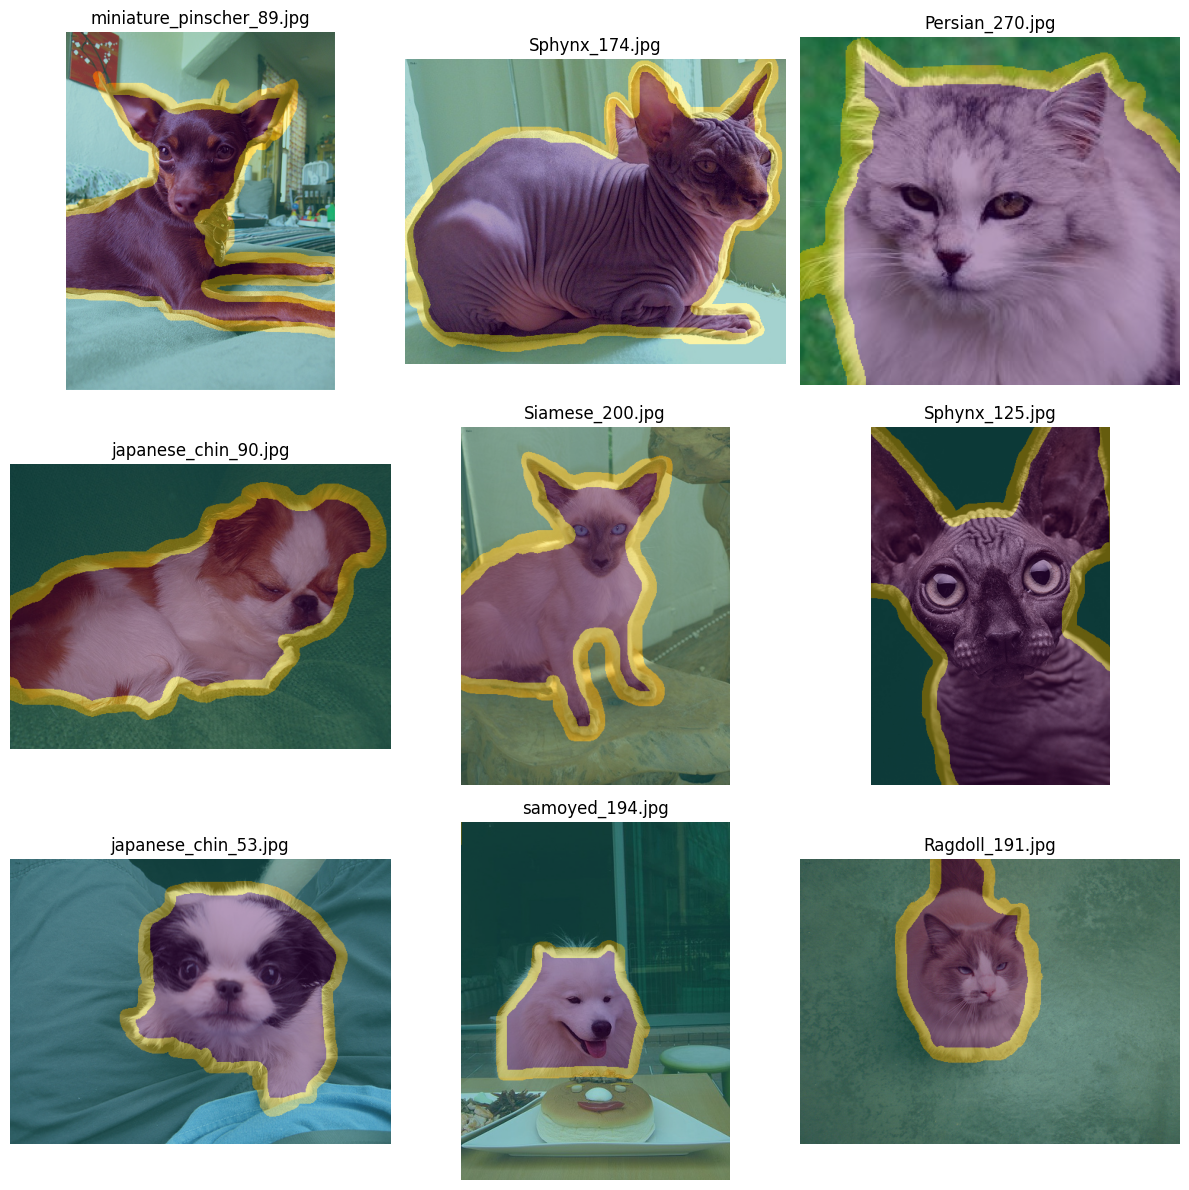

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

# get random images
image_files = random.sample(os.listdir("images"), 9)

plt.figure(figsize=(12,12))

for i, img_name in enumerate(image_files):

    # image load
    img_path = os.path.join("images", img_name)
    img = Image.open(img_path).convert("RGB")

    # annotation mask path
    mask_name = img_name.replace(".jpg", ".png")
    mask_path = os.path.join("annotations", "trimaps", mask_name)

    mask = Image.open(mask_path)

    # plot
    plt.subplot(3,3,i+1)
    plt.imshow(img)

    # overlay mask
    plt.imshow(mask, alpha=0.4)

    plt.title(img_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

def process_mask(mask_path):
    mask = Image.open(mask_path)
    mask = np.array(mask)

    # boundary pixels -> foreground
    mask[mask == 3] = 1

    # background = 0
    mask[mask == 2] = 0

    return mask

In [14]:
import os

print("Images exists:", os.path.exists("images"))
print("Masks exists:", os.path.exists("annotations/trimaps"))

Images exists: True
Masks exists: True


In [8]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
import os
import numpy as np
from PIL import Image

IMG_SIZE = 128

image_dir = "images"
mask_dir = "annotations/trimaps"

images = []
masks = []

for img_name in os.listdir(image_dir)[:3000]:

    img_path = os.path.join(image_dir, img_name)

    mask_name = img_name.replace(".jpg", ".png")
    mask_path = os.path.join(mask_dir, mask_name)

    # check mask exists
    if os.path.exists(mask_path):

        # image
        img = Image.open(img_path).convert("RGB")
        img = img.resize((IMG_SIZE, IMG_SIZE))
        img = np.array(img) / 255.0

        # mask
        mask = Image.open(mask_path)
        mask = mask.resize((IMG_SIZE, IMG_SIZE))
        mask = np.array(mask)

        # preprocess mask
        mask[mask == 3] = 1
        mask[mask == 2] = 0

        mask = np.expand_dims(mask, axis=-1)

        images.append(img)
        masks.append(mask)


images = np.array(images, dtype="float32")
masks = np.array(masks, dtype="float32")

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)

Images shape: (2999, 128, 128, 3)
Masks shape: (2999, 128, 128, 1)


In [15]:
from sklearn.model_selection import train_test_split

# 80% Train, 20% Temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    images,
    masks,
    test_size=0.20,
    random_state=42
)

# Temporary 20% -> 10% Validation + 10% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (2399, 128, 128, 3) (2399, 128, 128, 1)
Validation: (300, 128, 128, 3) (300, 128, 128, 1)
Test: (300, 128, 128, 3) (300, 128, 128, 1)


In [16]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from tensorflow.keras.models import Model


def build_unet():

    inputs = Input((IMG_SIZE, IMG_SIZE, 3))

    # Encoder
    c1 = Conv2D(32, 3, activation="relu", padding="same")(inputs)
    c1 = Conv2D(32, 3, activation="relu", padding="same")(c1)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(64, 3, activation="relu", padding="same")(p1)
    c2 = Conv2D(64, 3, activation="relu", padding="same")(c2)
    p2 = MaxPooling2D()(c2)

    c3 = Conv2D(128, 3, activation="relu", padding="same")(p2)
    c3 = Conv2D(128, 3, activation="relu", padding="same")(c3)
    p3 = MaxPooling2D()(c3)


    # Bottleneck
    b = Conv2D(256, 3, activation="relu", padding="same")(p3)
    b = Conv2D(256, 3, activation="relu", padding="same")(b)


    # Decoder
    u1 = UpSampling2D()(b)
    u1 = concatenate([u1, c3])
    c4 = Conv2D(128, 3, activation="relu", padding="same")(u1)
    c4 = Conv2D(128, 3, activation="relu", padding="same")(c4)


    u2 = UpSampling2D()(c4)
    u2 = concatenate([u2, c2])
    c5 = Conv2D(64, 3, activation="relu", padding="same")(u2)
    c5 = Conv2D(64, 3, activation="relu", padding="same")(c5)


    u3 = UpSampling2D()(c5)
    u3 = concatenate([u3, c1])
    c6 = Conv2D(32, 3, activation="relu", padding="same")(u3)
    c6 = Conv2D(32, 3, activation="relu", padding="same")(c6)


    outputs = Conv2D(1, 1, activation="sigmoid")(c6)


    model = Model(inputs, outputs)

    return model


model = build_unet()

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 128, 128,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 128, 128,  │      9,248 │ conv2d_15[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 64, 64,    │          0 │ conv2d_16[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 64, 64,    │     36,928 │ conv2d_17[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 32, 32,    │          0 │ conv2d_18[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 32, 32,    │    147,584 │ conv2d_19[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 16, 16,    │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 16, 16,    │    295,168 │ max_pooling2d_5[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 16, 16,    │    590,080 │ conv2d_21[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_3     │ (None, 32, 32,    │          0 │ conv2d_22[0][0]   │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 32, 32,    │          0 │ up_sampling2d_3[… │
│ (Concatenate)       │ 384)              │            │ conv2d_20[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 32, 32,    │    442,496 │ concatenate_3[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 32, 32,    │    147,584 │ conv2d_23[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_4     │ (None, 64, 64,    │          0 │ conv2d_24[0][0] 

 Total params: 1,946,881 (7.43 MB)

 Trainable params: 1,946,881 (7.43 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=16,
    epochs=10
)

Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 50s 197ms/step - accuracy: 0.6655 - loss: 0.6044 - val_accuracy: 0.7478 - val_loss: 0.5137
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.7776 - loss: 0.4794 - val_accuracy: 0.7884 - val_loss: 0.4701
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.8097 - loss: 0.4258 - val_accuracy: 0.8162 - val_loss: 0.4073
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.8285 - loss: 0.3893 - val_accuracy: 0.8278 - val_loss: 0.3826
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.8357 - loss: 0.3744 - val_accuracy: 0.8588 - val_loss: 0.3327
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.8504 - loss: 0.3464 - val_accuracy: 0.8563 - val_loss: 0.3379
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.8653 - loss: 0.3166 - val_accuracy: 0.8686 - val_loss: 0.3185
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.8718 - loss: 0.3030 -

In [18]:
# Prediction on Test Set
test_pred = model.predict(X_test, batch_size=8)

test_pred_bin = (test_pred > 0.5).astype(np.float32)
test_true_bin = (y_test > 0.5).astype(np.float32)

# IoU
intersection = np.sum(
    test_pred_bin * test_true_bin,
    axis=(1, 2, 3)
)

union = np.sum(
    test_pred_bin + test_true_bin,
    axis=(1, 2, 3)
) - intersection

test_iou = (intersection + 1e-7) / (union + 1e-7)

# Dice Score
test_dice = (2 * intersection + 1e-7) / (
    np.sum(test_pred_bin, axis=(1, 2, 3)) +
    np.sum(test_true_bin, axis=(1, 2, 3)) +
    1e-7
)

# Pixel Accuracy
test_pixel_accuracy = np.mean(test_pred_bin == test_true_bin)

print("Test Mean IoU:", np.mean(test_iou))
print("Test Mean Dice Score:", np.mean(test_dice))
print("Test Pixel Accuracy:", test_pixel_accuracy)
print("Test Pixel Accuracy (%):", test_pixel_accuracy * 100)

38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step
Test Mean IoU: 0.718172
Test Mean Dice Score: 0.8246306
Test Pixel Accuracy: 0.8709128824869792
Test Pixel Accuracy (%): 87.09128824869792


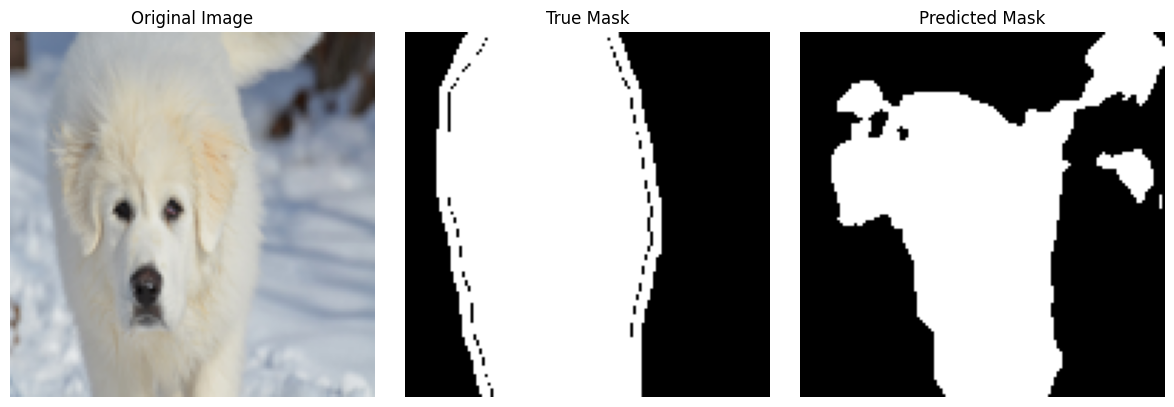

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Random test image
idx = np.random.randint(0, len(X_test))

image = X_test[idx]
true_mask = y_test[idx].squeeze()
pred_mask = test_pred_bin[idx].squeeze()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(true_mask, cmap="gray")
plt.title("True Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_mask, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.tight_layout()
plt.show()